In [1]:
from ipywidgets import interact

import cartopy.crs as ccrs
import cmcrameri.cm as ccm
from dask_ml.wrappers import ParallelPostFit
import gplately
import joblib
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.kernel_ridge import KernelRidge

from lib.main import *
from lib.plot import *

from parameters import parameters

In [2]:
# Plate model name
plate_model_name = parameters["plate_model_name"]

# Timespan for analysis
temporal_resolution = parameters["temporal_resolution"]
time_min = parameters["timespan"]["min"]
time_max = parameters["timespan"]["max"]
time_steps = range(time_min, time_max + temporal_resolution, temporal_resolution)

buffer_distance = parameters["buffer_distance"]
grid_resolution = parameters["grid_resolution"]

plate_model_dir = parameters["plate_model_dir"]
inputs_dir = parameters["inputs_dir"]
outputs_dir = parameters["outputs_dir"]
ml_dir = parameters["ml_dir"]
coastline_prob_grids_dir = parameters["coastline_prob_grids_dir"]
coastline_entropy_grids_dir = parameters["coastline_entropy_grids_dir"]
coastline_vote_variance_grids_dir = parameters["coastline_vote_variance_grids_dir"]
coastline_prob_maps_dir = parameters["coastline_prob_maps_dir"]
coastline_entropy_maps_dir = parameters["coastline_entropy_maps_dir"]
coastline_vote_variance_maps_dir = parameters["coastline_vote_variance_maps_dir"]

subduction_data_filename = parameters["subduction_data_filename"]
coastlines_filename = parameters["coastlines_filename"]
coastline_recon_nodes_filename = parameters["coastline_recon_nodes_filename"]
coastline_data_filename = parameters["coastline_data_filename"]
coastline_prob_filename = parameters["coastline_prob_filename"]
deposit_recon_coords_all_filename = parameters["deposit_recon_coords_all_filename"]
coastline_prob_present_day_filename = parameters["coastline_prob_present_day_filename"]
coastline_prob_present_day_grid_filename = parameters["coastline_prob_present_day_grid_filename"]
coastline_entropy_present_day_grid_filename = parameters["coastline_entropy_present_day_grid_filename"]
coastline_vote_variance_present_day_grid_filename = parameters["coastline_vote_variance_present_day_grid_filename"]
deposit_recon_coords_filename = parameters["deposit_recon_coords_filename"]

model_rf_calibrated_filename = parameters["model_rf_calibrated_filename"]
robust_scaler_filename = parameters["robust_scaler_filename"]

ml_dir = os.path.join(outputs_dir, ml_dir)
coastline_prob_grids_dir = os.path.join(ml_dir, coastline_prob_grids_dir)
coastline_entropy_grids_dir = os.path.join(ml_dir, coastline_entropy_grids_dir)
coastline_vote_variance_grids_dir = os.path.join(ml_dir, coastline_vote_variance_grids_dir)
coastline_prob_maps_dir = os.path.join(ml_dir, coastline_prob_maps_dir)
coastline_entropy_maps_dir = os.path.join(ml_dir, coastline_entropy_maps_dir)
coastline_vote_variance_maps_dir = os.path.join(ml_dir, coastline_vote_variance_maps_dir)

subduction_data_filename = os.path.join(outputs_dir, subduction_data_filename)
coastlines_filename = os.path.join(inputs_dir, coastlines_filename)
coastline_recon_nodes_filename = os.path.join(outputs_dir, coastline_recon_nodes_filename)
coastline_data_filename = os.path.join(outputs_dir, coastline_data_filename)
coastline_prob_filename = os.path.join(ml_dir, coastline_prob_filename)
deposit_recon_coords_all_filename = os.path.join(outputs_dir, deposit_recon_coords_all_filename)
coastline_prob_present_day_filename = os.path.join(ml_dir, coastline_prob_present_day_filename)
coastline_prob_present_day_grid_filename = os.path.join(ml_dir, coastline_prob_present_day_grid_filename)
coastline_entropy_present_day_grid_filename = os.path.join(ml_dir, coastline_entropy_present_day_grid_filename)
coastline_vote_variance_present_day_grid_filename = os.path.join(ml_dir, coastline_vote_variance_present_day_grid_filename)
deposit_recon_coords_filename = os.path.join(outputs_dir, deposit_recon_coords_filename)

model_rf_calibrated_filename = os.path.join(ml_dir, model_rf_calibrated_filename)
robust_scaler_filename = os.path.join(ml_dir, robust_scaler_filename)

agegrid_dir = os.path.join(inputs_dir, "SeafloorAge")
crusthick_dir = os.path.join(inputs_dir, "CrustalThickness")

nprocs = 20

In [3]:
plate_model = get_plate_reconstruction(
    model_name=plate_model_name,
    model_dir=plate_model_dir,
)

gplot = get_plot_topologies(
    model_name=plate_model_name,
    model_dir=plate_model_dir,
    plate_reconstruction=plate_model,
    filter_topologies=True,
)

projection = ccrs.Mollweide(central_longitude=60)
central_meridian = 0

In [4]:
if os.path.isfile(coastline_recon_nodes_filename):
    coastline_recon_nodes = pd.read_csv(coastline_recon_nodes_filename)
else:
    coastline_recon_nodes = reconstruct_coastline_nodes(
        coastlines=coastlines_filename,
        resolution=grid_resolution,
        time_steps=time_steps,
        plate_reconstruction=plate_model,
        output_filename=coastline_recon_nodes_filename,
        verbose=True,
    )

In [5]:
@interact
def show_map(time=time_steps):
    gplot.time = time    
    
    agegrid_filename =  f'seafloor_age_{time}Ma.nc'
    agegrid_file = os.path.join(agegrid_dir, agegrid_filename)    
    agegrid = gplately.grids.read_netcdf_grid(agegrid_file)
    
    fig = plt.figure(figsize=(16, 12))
    ax = plt.axes(
        projection=projection,
        facecolor=(plt.cm.colors.to_rgba('darkgray', alpha=0.5))
    )

    im = gplot.plot_grid(ax, agegrid.data, cmap=ccm.lapaz_r, vmin=0, vmax=230, alpha=0.7, zorder=1)

    gplot.plot_coastlines(ax, facecolor='darkgray', edgecolor='none', zorder=2)
    gplot.plot_plate_motion_vectors(ax, spacingX=10, spacingY=10, normalise=True, alpha=0.1, zorder=3)

    # buffer_zones_t_filename = f'buffer_zones_{time}Ma.geojson'
    # buffer_zones_t_filename = os.path.join(buffer_zones_dir, buffer_zones_t_filename)
    # buffer_zones_t = gpd.read_file(buffer_zones_t_filename)

    # buffer_zones_t.plot(
    #     ax=ax,
    #     transform=ccrs.PlateCarree(),
    #     facecolor='palegreen',
    #     edgecolor='none',
    #     alpha=0.7,
    #     zorder=4,
    # )

    coastline_recon_nodes_t = coastline_recon_nodes[coastline_recon_nodes["age (Ma)"] == time]

    gplot.plot_all_topologies(ax, color='dimgray', linewidth=1.5, zorder=5)

    ax.scatter(
        coastline_recon_nodes_t['lon'],
        coastline_recon_nodes_t['lat'],
        transform=ccrs.PlateCarree(),
        marker='.',
        c='red',
        s=1,
        alpha=0.5,
        zorder=6
    )
    
    gplot.plot_trenches(ax, color='k', alpha=0.3, zorder=7)
    gplot.plot_subduction_teeth(ax, spacing=0.05, color='k', alpha=0.3, zorder=8)

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, x_inline=False, linewidth=1, color="gray", alpha=0.3, linestyle="--", zorder=9)

    ax.text(0.49,-0.03, '60°E', transform=ax.transAxes, fontsize=16)
    ax.text(0.46,-0.03, '0°', transform=ax.transAxes, fontsize=16)
    ax.text(0.40,-0.025, '60°W', transform=ax.transAxes, fontsize=16)
    
    gl.top_labels=False
    gl.bottom_labels=False
    
    gl.xlabel_style = {"size": 16}
    gl.ylabel_style = {"size": 16}
    
    cb = fig.colorbar(im, orientation='horizontal', shrink=0.4, pad=0.06, extend='max')
    cb.set_label("Seafloor Age (Ma)", fontsize=16, labelpad=10)
    cb.set_ticks([0, 50, 100, 150, 200])
    cb.ax.tick_params(labelsize=16)
    
    # Define custom legend handles
    custom_handles = [
        Patch(facecolor='darkgray', edgecolor='none', label='Continental Crust'),
        # Patch(facecolor='palegreen', edgecolor='none', alpha=0.7, label='Target Areas in\nBack-Arc Basins'),
        Line2D([0], [0], color='dimgray', lw=2, label='Mid-Ocean Ridges'),
        Line2D([0], [0], marker='.', markerfacecolor='red', markeredgecolor='none', markersize=10, linestyle='None', label='Target Points')
    ]

    # Add the custom legend to the plot
    ax.legend(handles=custom_handles, fontsize=16, loc='lower left', bbox_to_anchor=(0, -0.25))

    ax.set_title(f'{time} Ma', fontsize=25, y=1.04)
        
    plt.show()

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

In [6]:
if os.path.isfile(coastline_data_filename):
    coastline_data = pd.read_csv(coastline_data_filename)
else:
    subduction_data = pd.read_csv(subduction_data_filename)
    
    coastline_data = run_coregister_point_data(
        point_data=coastline_recon_nodes,
        subduction_data=subduction_data,
        # output_filename=coastline_data_filename,
        distance_threshold=buffer_distance,
        n_jobs=nprocs,
        verbose=True,
    )
    
    coastline_data = run_coregister_crustal_thickness(
        point_data=coastline_data,
        input_dir=crusthick_dir,
        output_filename=coastline_data_filename,
        n_jobs=nprocs,
        verbose=True,
    )

In [7]:
if os.path.isfile(coastline_prob_filename):
    print(f"Probabilities have already been calculated and saved in {coastline_prob_filename}\nLoading ...")
    coastline_prob = pd.read_csv(coastline_prob_filename)
else:
    # Load model and scaler
    model_rf_calibrated = joblib.load(model_rf_calibrated_filename)
    model_rf_calibrated.n_jobs = nprocs
    robust_scaler = joblib.load(robust_scaler_filename)

    # Filter valid rows
    coastline_valid = coastline_data[coastline_data["valid"]].copy()

    # Scale the features
    selected_features = model_rf_calibrated.feature_names_in_
    coastline_valid_scaled = robust_scaler.transform(coastline_valid[selected_features])
    coastline_valid_scaled = pd.DataFrame(coastline_valid_scaled, columns=selected_features)

    # Predict probabilities
    model_rf_parallel = ParallelPostFit(model_rf_calibrated)
    probs = model_rf_parallel.predict_proba(coastline_valid_scaled)[:, 1].ravel()

    # Calculate metrics
    entropies = calculate_entropy(probs)
    print(f"Calculating vote variance ...")
    vote_variances = calculate_tree_vote_variance(
        model_rf_calibrated.estimator,
        coastline_valid_scaled.values,
        n_jobs=nprocs,
        verbose=True
    )

    # Prepare final DataFrame with only valid rows
    columns_prob = [
        "index",
        "lon",
        "lat",
        "age (Ma)",
    ]

    coastline_prob = coastline_valid[columns_prob].copy()
    coastline_prob["probability"] = probs
    coastline_prob["entropy"] = entropies
    coastline_prob["vote_variance"] = vote_variances
    
    # Export only valid rows with calculated metrics
    print(f"Saving the metrics as a CSV file: {coastline_prob_filename}")
    coastline_prob.to_csv(coastline_prob_filename, index=False)

if os.path.exists(coastline_prob_grids_dir):
    print(f"Probability grids are located in {coastline_prob_grids_dir}")
else:
    os.makedirs(coastline_prob_grids_dir, exist_ok=True)

    create_grids(
        data=coastline_prob_filename,
        output_dir=coastline_prob_grids_dir,
        times=time_steps,
        resolution=grid_resolution,
        extent=(-180, 180, -90, 90),
        interpolation=True,
        threads=nprocs,
        verbose=True,
        column="probability",
        filename_format="coastline_probability_grid_{}Ma.nc",
    )


if os.path.exists(coastline_entropy_grids_dir):
    print(f"Entropy grids are located in {coastline_entropy_grids_dir}")
else:
    os.makedirs(coastline_entropy_grids_dir, exist_ok=True)

    create_grids(
        data=coastline_prob_filename,
        output_dir=coastline_entropy_grids_dir,
        times=time_steps,
        resolution=grid_resolution,
        extent=(-180, 180, -90, 90),
        interpolation=True,
        threads=nprocs,
        verbose=True,
        column="entropy",
        filename_format="coastline_entropy_grid_{}Ma.nc",
    )


if os.path.exists(coastline_vote_variance_grids_dir):
    print(f"Vote variance grids are located in {coastline_vote_variance_grids_dir}")
else:
    os.makedirs(coastline_vote_variance_grids_dir, exist_ok=True)

    create_grids(
        data=coastline_prob_filename,
        output_dir=coastline_vote_variance_grids_dir,
        times=time_steps,
        resolution=grid_resolution,
        extent=(-180, 180, -90, 90),
        interpolation=True,
        threads=nprocs,
        verbose=True,
        column="vote_variance",
        filename_format="coastline_vote_variance_grid_{}Ma.nc",        
    )

Probabilities have already been calculated and saved in outputs\ml\coastline_prob.csv
Loading ...
Probability grids are located in outputs\ml\coastline_prob_grids
Entropy grids are located in outputs\ml\coastline_entropy_grids
Vote variance grids are located in outputs\ml\coastline_vote_variance_grids


### Probability Maps

In [8]:
@interact
def show_map(time=time_steps):
    gplot.time = time
    fig = plot(
        gplot=gplot,
        grid=os.path.join(
            coastline_prob_grids_dir,
            f"coastline_probability_grid_{time:0.0f}Ma.nc",
        ),
        grid_type="probability",
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc",
        ),
        positives=deposit_recon_coords_all_filename,
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

In [9]:
if os.path.exists(coastline_prob_maps_dir):
    print(f"Probability maps are located in {coastline_prob_maps_dir}")
else:
    os.makedirs(coastline_prob_maps_dir, exist_ok=True)

    with Parallel(
        n_jobs=nprocs,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // nprocs) + 1,
    ) as parallel:

        # Create all plots
        output_filenames = [
            os.path.join(coastline_prob_maps_dir, f"coastline_probability_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot)(
                gplot=gplot,
                grid=os.path.join(
                    coastline_prob_grids_dir,
                    f"coastline_probability_grid_{t:0.0f}Ma.nc",
                ),
                grid_type="probability",
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                positives=deposit_recon_coords_all_filename,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create animation
    output_filename = os.path.join(ml_dir, "coastline_probability_animation.mp4")
    create_animation(
        image_filenames=output_filenames[::-1],
        output_filename=output_filename,
        fps=10,
        bitrate="5000k",
    )

Probability maps are located in outputs\ml\coastline_prob_maps


### Entropy Maps

In [10]:
@interact
def show_map(time=time_steps):
    gplot.time = time
    fig = plot(
        gplot=gplot,
        grid=os.path.join(
            coastline_entropy_grids_dir,
            f"coastline_entropy_grid_{time:0.0f}Ma.nc",
        ),
        grid_type="entropy",
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc",
        ),
        positives=deposit_recon_coords_all_filename,
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

In [11]:
if os.path.exists(coastline_entropy_maps_dir):
    print(f"Entropy maps are located in {coastline_entropy_maps_dir}")
else:
    os.makedirs(coastline_entropy_maps_dir, exist_ok=True)

    with Parallel(
        n_jobs=nprocs,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // nprocs) + 1,
    ) as parallel:

        # Create all plots
        output_filenames = [
            os.path.join(coastline_entropy_maps_dir, f"coastline_entropy_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot)(
                gplot=gplot,
                grid=os.path.join(
                    coastline_entropy_grids_dir,
                    f"coastline_entropy_grid_{t:0.0f}Ma.nc",
                ),
                grid_type="entropy",
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                positives=deposit_recon_coords_all_filename,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create animation
    output_filename = os.path.join(ml_dir, "coastline_entropy_animation.mp4")
    create_animation(
        image_filenames=output_filenames[::-1],
        output_filename=output_filename,
        fps=10,
        bitrate="5000k",
    )

Entropy maps are located in outputs\ml\coastline_entropy_maps


### Vote Variance Maps

In [12]:
@interact
def show_map(time=time_steps):
    gplot.time = time
    fig = plot(
        gplot=gplot,
        grid=os.path.join(
            coastline_vote_variance_grids_dir,
            f"coastline_vote_variance_grid_{time:0.0f}Ma.nc",
        ),
        grid_type="vote variance",
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc",
        ),
        positives=deposit_recon_coords_all_filename,
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

In [13]:
if os.path.exists(coastline_vote_variance_maps_dir):
    print(f"Vote variance maps are located in {coastline_vote_variance_maps_dir}")
else:
    os.makedirs(coastline_vote_variance_maps_dir, exist_ok=True)

    with Parallel(
        n_jobs=nprocs,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // nprocs) + 1,
    ) as parallel:

        # Create all plots
        output_filenames = [
            os.path.join(coastline_vote_variance_maps_dir, f"coastline_vote_variance_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot)(
                gplot=gplot,
                grid=os.path.join(
                    coastline_vote_variance_grids_dir,
                    f"coastline_vote_variance_grid_{t:0.0f}Ma.nc",
                ),
                grid_type="vote variance",
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                positives=deposit_recon_coords_all_filename,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create animation
    output_filename = os.path.join(ml_dir, "coastline_vote_variance_animation.mp4")
    create_animation(
        image_filenames=output_filenames[::-1],
        output_filename=output_filename,
        fps=10,
        bitrate="5000k",
    )

Vote variance maps are located in outputs\ml\coastline_vote_variance_maps


### Global Prospectivity Map of Porphyry Mineralisation

In [14]:
if os.path.isfile(coastline_prob_present_day_filename):
    coastline_prob_present_day = pd.read_csv(coastline_prob_present_day_filename)
else:
    coastline_prob = coastline_prob[coastline_prob['probability'] > 0.5]
    coastline_prob_mean = coastline_prob.groupby('index')[['probability', 'entropy', 'vote_variance']].mean().reset_index()
    present_day_coords = coastline_data[coastline_data['age (Ma)'] == 0][['index', 'lon', 'lat']]
    coastline_prob_present_day = pd.merge(coastline_prob_mean, present_day_coords, on='index', how='left')
    coastline_prob_present_day = coastline_prob_present_day[['index', 'lon', 'lat', 'probability', 'entropy', 'vote_variance']]
    coastline_prob_present_day.to_csv(coastline_prob_present_day_filename, index=False)

In [22]:
model_rf_calibrated = joblib.load(model_rf_calibrated_filename)
selected_features = model_rf_calibrated.feature_names_in_

deposit_recon_coords = pd.read_csv(deposit_recon_coords_filename)

# Rolling window to smooth the curve
coastline_prob = coastline_prob[coastline_prob['probability'] > 0.5]
coastline_prob_mean_age = coastline_prob.groupby('age (Ma)')['probability'].mean().reset_index()
coastline_prob_mean_age['smoothed'] = coastline_prob_mean_age['probability'].rolling(window=10, center=True).mean()

# Sort by age to ensure correct ordering
coastline_prob_mean_age = coastline_prob_mean_age.sort_values('age (Ma)')

# Define input and target
ages = coastline_prob_mean_age['age (Ma)'].values.reshape(-1, 1)
probs = coastline_prob_mean_age['probability'].values

ages_smooth, probs_smooth = smooth_curve(ages, probs)

@interact
def show_map(feature=selected_features):
    coastline_feat_mean_age = coastline_prob.merge(coastline_data[['index', 'age (Ma)', feature]], on=['index', 'age (Ma)'], how='left')
    coastline_feat_mean_age = coastline_feat_mean_age.groupby('age (Ma)')[feature].mean().reset_index()
    coastline_feat_mean_age = coastline_feat_mean_age.sort_values('age (Ma)')
    feat_vals = coastline_feat_mean_age[feature].values
    _, feat_vals_smooth = smooth_curve(ages, feat_vals)
    
    # Set up plot with dual y-axes
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.set_facecolor('whitesmoke')
    
    # Plot smoothed probability line
    # ax1.plot(data['age (Ma)'], data['smoothed'], 'r-', alpha=0.5, label='Rolling Mean')
    ax1.plot(ages_smooth, probs_smooth, color='orangered', linewidth=2, label='KRR Smoothed')
    ax1.set_xlim(540, 0)
    ax1.set_ylim(0.65, 0.85)
    ax1.set_xlabel('Age (Ma)')
    ax1.set_ylabel('Mean probability (P > 0.5)', color='orangered')
    # ax1.set_title('Mean Probability and Deposit Frequency by Age')
    # ax1.grid(True, linestyle='--')
    
    # Create secondary y-axis for histogram
    ax2 = ax1.twinx()
    
    # Plot histogram
    ax2.hist(deposit_recon_coords['age (Ma)'], bins=40, orientation='vertical', color='LightSalmon', alpha=0.5, edgecolor='gray')
    ax2.set_ylabel('Deposit count')
    
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))  # shift third axis to the right
    ax3.plot(ages_smooth, feat_vals_smooth,
             linestyle='-', color='royalblue', label=format_feature_name(feature))
    ax3.set_ylabel(format_feature_name(feature), color='royalblue')
    # ax3.tick_params(axis='y', labelcolor='royalblue')
    
    # # Add legends
    # lines1, labels1 = ax1.get_legend_handles_labels()
    # lines3, labels3 = ax3.get_legend_handles_labels()
    # ax1.legend(lines1 + lines3, labels1 + labels3, loc='upper left')
    
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='feature', options=('arc_segment_length (degrees)', 'carbonate_thic…

In [23]:
if not os.path.isfile(coastline_prob_present_day_grid_filename):
    for column, filename in zip(
        ['probability', 'entropy', 'vote_variance'],
        [
            coastline_prob_present_day_grid_filename,
            coastline_entropy_present_day_grid_filename,
            coastline_vote_variance_present_day_grid_filename
        ]
    ):
        xmin, xmax, ymin, ymax = -180, 180, -90, 90

        # Create the grid
        grid_lons = np.arange(xmin, xmax + grid_resolution, grid_resolution)
        grid_lats = np.arange(ymin, ymax + grid_resolution, grid_resolution)
        grid_mlons, grid_mlats = np.meshgrid(grid_lons, grid_lats)

        data_lons = coastline_prob_present_day['lon']
        data_lats = coastline_prob_present_day['lat']
        data_values = coastline_prob_present_day[column]

        # Interpolate
        points = np.column_stack((data_lons, data_lats))
        arr = griddata(points, data_values, (grid_mlons, grid_mlats), method="nearest")  # or "linear", "cubic"

        # Mask distant grid nodes
        tree = cKDTree(points)
        flat_grid_points = np.column_stack((grid_mlons.ravel(), grid_mlats.ravel()))
        distances, _ = tree.query(flat_grid_points, k=1)

        mask = distances > grid_resolution
        arr.ravel()[mask] = np.nan  # Mask out distant nodes        

        # Create the dataset
        dset = xr.Dataset(
            data_vars={
                "z": (("lat", "lon"), arr),
            },
            coords={
                "lon": grid_lons,
                "lat": grid_lats,
            },
        )

        # Set projection info
        dset.rio.write_crs(4326, inplace=True)

        # Save as NetCDF
        dset.to_netcdf(
            filename,
            encoding={
                "z": {
                    "zlib": True,
                    "dtype": "float32",
                }
            },
        )

In [24]:
deposit_recon_coords_all = pd.read_csv(deposit_recon_coords_all_filename)
time = 0

gplot.time = time

deposit_recon_coords_t = deposit_recon_coords_all[[f'lon_{time}', f'lat_{time}', 'weight']]
deposit_recon_coords_t = deposit_recon_coords_t.dropna()
    
agegrid_filename =  f'seafloor_age_{time}Ma.nc'
agegrid_file = os.path.join(agegrid_dir, agegrid_filename)    
agegrid = gplately.grids.read_netcdf_grid(agegrid_file)

map_types = ['Probability', 'Entropy', 'Vote Variance']

@interact
def show_map(map_type=map_types):
    if map_type==map_types[0]:
        raster = Raster(coastline_prob_present_day_grid_filename)
        raster.data *= 100.0
    elif map_type==map_types[1]:
        raster = Raster(coastline_entropy_present_day_grid_filename)
    elif map_type==map_types[2]:
        raster = Raster(coastline_vote_variance_present_day_grid_filename)

    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_axes(
        [0.1, 0.1, 0.8, 0.8],
        projection=projection,
        facecolor=(plt.cm.colors.to_rgba('darkgray', alpha=0.5)),
    )

    cax_grd = fig.add_axes([0.1, 0.12, 0.35, 0.02])
    cax_bg = fig.add_axes([0.55, 0.12, 0.35, 0.02])

    bg = gplot.plot_grid(ax, agegrid.data, cmap=ccm.lapaz_r, vmin=0, vmax=230, alpha=0.7, zorder=1)

    gplot.plot_coastlines(ax, facecolor='darkgray', edgecolor='none', zorder=2)
    gplot.plot_plate_motion_vectors(ax, spacingX=10, spacingY=10, normalise=True, alpha=0.1, zorder=3)

    if map_type==map_types[0]:
        # grd = raster.imshow(ax=ax, cmap=ccm.hawaii_r, vmin=0, vmax=100, alpha=0.9, zorder=4)
        grd = raster.imshow(ax=ax, cmap=ccm.hawaii_r, vmin=50, vmax=100, alpha=0.9, zorder=4)
    elif map_type==map_types[1]:
        grd = raster.imshow(ax=ax, cmap=ccm.hawaii_r, vmin=0, vmax=1, alpha=0.9, zorder=4)
    elif map_type==map_types[2]:
        grd = raster.imshow(ax=ax, cmap=ccm.hawaii_r, vmin=0, vmax=0.25, alpha=0.9, zorder=4)

    gplot.plot_all_topologies(ax, color='dimgray', linewidth=1.5, zorder=5)
    gplot.plot_trenches(ax, color='k', alpha=0.3, zorder=6)
    gplot.plot_subduction_teeth(ax, spacing=0.05, color='k', alpha=0.3, zorder=7)

    sc1 = ax.scatter(
        deposit_recon_coords_t[f'lon_{time}'],
        deposit_recon_coords_t[f'lat_{time}'],
        transform=ccrs.PlateCarree(),
        marker='o',
        facecolor='yellow',
        edgecolor='black',
        s = [w * 10 for w in deposit_recon_coords_t['weight']],
        alpha=0.3,
        zorder=8
    )

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, x_inline=False, linewidth=1, color="gray", alpha=0.3, linestyle="--", zorder=9)

    ax.text(0.49,-0.03, '60°E', transform=ax.transAxes, fontsize=16)
    ax.text(0.46,-0.03, '0°', transform=ax.transAxes, fontsize=16)
    ax.text(0.40,-0.025, '60°W', transform=ax.transAxes, fontsize=16)

    gl.top_labels=False
    gl.bottom_labels=False

    gl.xlabel_style = {"size": 16}
    gl.ylabel_style = {"size": 16}

    cbar_grd = fig.colorbar(grd, cax=cax_grd, orientation="horizontal")
    if map_type==map_types[0]:
        cbar_grd.set_label("Mineralisation Probability", fontsize=16, labelpad=10)
    elif map_type==map_types[1]:
        cbar_grd.set_label("Entropy", fontsize=16, labelpad=10)
    elif map_type==map_types[2]:
        cbar_grd.set_label("Vote Variance", fontsize=16, labelpad=10)
    cbar_grd.ax.tick_params(labelsize=16)

    cbar_bg = fig.colorbar(bg, cax=cax_bg, orientation="horizontal", extend='max')
    cbar_bg.set_label("Seafloor Age (Ma)", fontsize=16, labelpad=10)
    cbar_bg.set_ticks([0, 50, 100, 150, 200])
    cbar_bg.ax.tick_params(labelsize=16)

    # Define custom legend handles
    custom_handles = [
        Patch(facecolor='darkgray', edgecolor='none', label='Continental Crust'),
        Line2D([0], [0], color='dimgray', lw=2, label='Mid-Ocean Ridges'),
        Line2D([0], [0], marker='o', markerfacecolor='yellow', markeredgecolor='black', markersize=15, linestyle='None', label='Mineral Occurrence')
    ]

    # Add the custom legend to the plot
    legend = ax.legend(handles=custom_handles, fontsize=16, loc='lower left', bbox_to_anchor=(0, -0.15))

#     ax.set_title('Global Prospectivity Map of Porphyry Mineralisation', fontsize=25, y=1.04)

    plt.show()

interactive(children=(Dropdown(description='map_type', options=('Probability', 'Entropy', 'Vote Variance'), va…

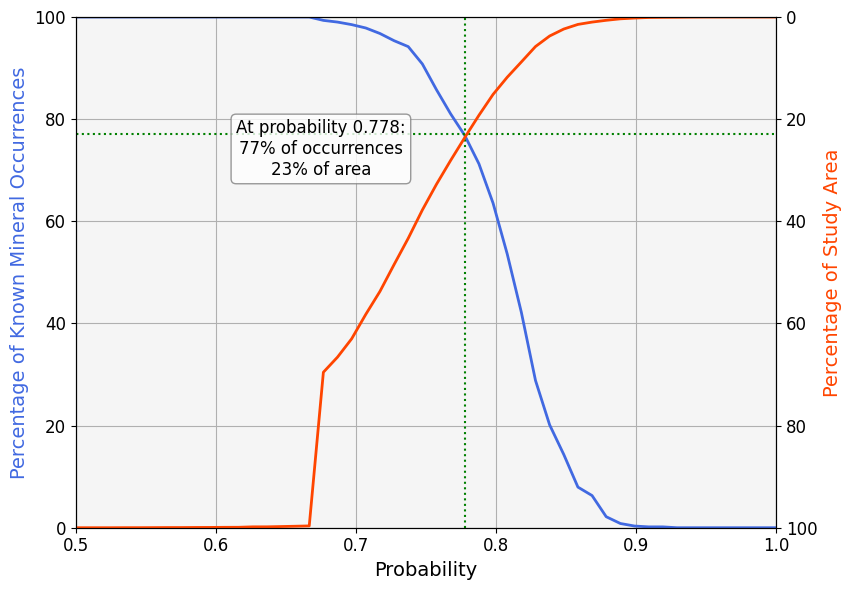

In [25]:
# Load prospectivity data
prospectivity_data = xr.open_dataset(coastline_prob_present_day_grid_filename)
prospectivity_data = prospectivity_data['z'].squeeze()

# Extract probability values at known mineral occurrence locations
occurrence_probabilities = []
for _, row in deposit_recon_coords.iterrows():
    lon, lat = row['present_lon'], row['present_lat']
    # Extract probability value at this point
    prob_value = prospectivity_data.sel(lon=lon, lat=lat, method='nearest').item()
    occurrence_probabilities.append(prob_value)

# Convert to numpy array for easier manipulation
occurrence_probabilities = np.array(occurrence_probabilities)
occurrence_probabilities = occurrence_probabilities[~np.isnan(occurrence_probabilities)]

# Calculate total study area and number of valid cells
total_area = np.count_nonzero(~np.isnan(prospectivity_data))
total_occurrences = len(occurrence_probabilities)

# Define the probability thresholds
thresholds = np.linspace(0, 1, 100)

# Initialize lists to store results
occurrence_percentages = []
area_percentages = []

# Calculate percentages for each threshold
for threshold in thresholds:
    occurrence_percentage = np.sum(occurrence_probabilities >= threshold) / total_occurrences * 100
    area_percentage = np.sum(prospectivity_data >= threshold) / total_area * 100
    occurrence_percentages.append(occurrence_percentage)
    area_percentages.append(area_percentage)

# Convert lists to numpy arrays for plotting
occurrence_percentages = np.array(occurrence_percentages)
area_percentages = np.array(area_percentages)

# Set the font sizes
SMALL_SIZE = 12
MEDIUM_SIZE = 14
LARGE_SIZE = 16

# Create the P-A plot
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_facecolor('whitesmoke')

# Plot the occurrence percentages
ax1.plot(thresholds, occurrence_percentages, color='royalblue', linewidth=2)
ax1.set_xlabel('Probability', fontsize=MEDIUM_SIZE)
ax1.set_ylabel('Percentage of Known Mineral Occurrences', color='royalblue', fontsize=MEDIUM_SIZE)
ax1.set_ylim(0, 100)
ax1.set_xlim(0.5, 1)
ax1.grid(True)

# Increase tick label sizes
ax1.tick_params(axis='both', labelsize=SMALL_SIZE)

# Create a second y-axis to plot the area percentages
ax2 = ax1.twinx()
ax2.plot(thresholds, area_percentages, color='orangered', linewidth=2)
ax2.set_ylabel('Percentage of Study Area', color='orangered', fontsize=MEDIUM_SIZE)
ax2.set_ylim(100, 0)  # Inverted y-axis
ax2.tick_params(axis='y', labelsize=SMALL_SIZE)

# Add horizontal and vertical lines
intersection_x = 0.778
intersection_y1 = 77
intersection_y2 = 23
h_line = ax1.hlines(y=intersection_y1, xmin=0, xmax=1, color='g', linestyles=':')
v_line = ax1.vlines(x=intersection_x, ymin=0, ymax=100, color='g', linestyles=':')

# Add annotations for the lines
# X-axis annotation
# ax1.annotate(f'{intersection_x}', xy=(intersection_x, -0.06), xycoords='data',
#              xytext=(0, -20), textcoords='offset points',
#              ha='center', va='top', color='g',
#              arrowprops=dict(arrowstyle='->', color='g'))

# # Left Y-axis (Percentage of Known Mineral Occurrences) annotation
# ax1.annotate(f'{intersection_y1}%', xy=(0, intersection_y1), xycoords='data',
#              xytext=(-25, 0), textcoords='offset points',
#              ha='right', va='center', color='g',
#              arrowprops=dict(arrowstyle='->', color='g', shrinkA=0, shrinkB=4))

# # Right Y-axis (Percentage of Study Area) annotation
# ax2.annotate(f'{intersection_y2}%', xy=(1, intersection_y2), xycoords='data',
#              xytext=(25, 0), textcoords='offset points',
#              ha='left', va='center', color='g',
#              arrowprops=dict(arrowstyle='->', color='g', shrinkA=0, shrinkB=4))

# Add a text box to explain the intersection point with larger font
ax1.annotate(f'At probability {intersection_x}:\n{intersection_y1}% of occurrences\n{intersection_y2}% of area',
             xy=(0.35, 0.8), xycoords='axes fraction',
             ha='center', va='top',
             fontsize=SMALL_SIZE,
             bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))

# plt.title('Prediction-Area Plot')
plt.tight_layout()  # Adjust layout to prevent clipping of labels

# Adjust the plot margins to make room for annotations
plt.subplots_adjust(left=0.15, right=0.85)

# plt.savefig(
# f'./figures/pa_ng.png',
# bbox_inches='tight',
# pad_inches=0.1,
# dpi=200
# )

plt.show()